# Quinquennial Panel Analysis (1970–2020)

**Data**: Fraser Institute Economic Freedom of the World Index  
**Focus**: 11 quinquennial waves for balanced panel analysis

This notebook is **purely quinquennial** (no annual data mixing) and emphasizes:

1. **Balanced vs Unbalanced** comparisons throughout
2. **Distribution bands** (median, p10/p90), not just means
3. **Gap-to-world** plots instead of redundant level plots
4. **Reform intensity** tracking with component drivers

All interpretations are purely **descriptive**—no causal claims.

## 0. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

import efw_utils as efw

# Configuration
DATA_PATH = "data/fraser.xlsx"
OUTPUT_DIR = "outputs"
TABLES_DIR = "outputs/tables"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# Column names
EFW = efw.EFW_COL
AREAS = efw.AREA_COLS
LABELS = efw.AREA_LABELS
COLORS = efw.AREA_COLORS
REGION = 'Region'
INCOME = 'Income_Group'

# Quinquennial years ONLY
QUIN = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]
PERIODS = [(1990, 2000), (2000, 2010), (2010, 2020)]

efw.setup_plot_style()
fig_index = efw.FigureIndex()

print(f"Quinquennial years: {QUIN}")

Quinquennial years: [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]


## 1. Data Preparation

In [2]:
df_full = efw.load_fraser(DATA_PATH, verbose=True)

# Filter to quinquennial years ONLY
df = df_full[df_full['Year'].isin(QUIN)].copy()

# Add area availability tracking
df = efw.add_area_availability(df, AREAS)

print(f"\nQuinquennial subset: {len(df):,} obs, {df['Countries'].nunique()} countries, {len(QUIN)} waves")

Loaded Fraser EFW data:
  Observations: 4,950
  Years: 1970–2023
  Countries: 165

Quinquennial subset: 1,815 obs, 165 countries, 11 waves


### Data Validation

In [3]:
# Uniqueness check
assert df.groupby(['Year', 'Countries']).size().max() == 1, "Duplicate country-years found!"
print("✓ No duplicate country-years")

# Range checks
for c in [EFW] + AREAS:
    x = df[c].dropna()
    assert x.between(0, 10).all(), f"{c} has out-of-range values"
print("✓ All scores within [0, 10]")

# Validate EFW = mean(available areas)
max_abs = efw.validate_overall_matches_available_areas(df, EFW, AREAS, tol=0.01)
print(f"✓ EFW = mean(available areas): max|diff| = {max_abs:.4f}")

# Income group coverage (should be missing pre-1990)
pre1990_income = df[df['Year'] < 1990][INCOME].notna().sum()
print(f"Income_Group pre-1990: {pre1990_income} non-missing (expected ~0)")

# Area completeness by wave
print("\nArea completeness by wave:")
completeness = df.groupby('Year')[['n_areas', 'complete5']].agg({
    'n_areas': 'mean',
    'complete5': ['sum', 'mean']
})
completeness.columns = ['mean_n_areas', 'N_complete5', 'share_complete5']
print(completeness.to_string())

✓ No duplicate country-years
✓ All scores within [0, 10]
✓ EFW = mean(available areas): max|diff| = 0.0050
Income_Group pre-1990: 0 non-missing (expected ~0)

Area completeness by wave:
      mean_n_areas  N_complete5  share_complete5
Year                                            
1970      3.272727           72         0.436364
1975      3.527273           94         0.569697
1980      3.642424          101         0.612121
1985      3.818182          105         0.636364
1990      4.048485          108         0.654545
1995      4.248485          113         0.684848
2000      4.721212          129         0.781818
2005      4.818182          141         0.854545
2010      4.890909          152         0.921212
2015      4.933333          159         0.963636
2020      5.000000          165         1.000000


## 2. Panel Balance

In [4]:
# Count waves per country
obs_per_country = df.groupby('Countries')[EFW].apply(lambda x: x.notna().sum())
balanced_countries = obs_per_country[obs_per_country == len(QUIN)].index.tolist()
df_bal = df[df['Countries'].isin(balanced_countries)].copy()

print(f"Balanced panel: {len(balanced_countries)} countries in all {len(QUIN)} waves")
print(f"Unbalanced: {df['Countries'].nunique()} total countries")

# Coverage distribution
coverage_dist = obs_per_country.value_counts().sort_index(ascending=False)
print("\nCoverage distribution:")
for waves, count in coverage_dist.items():
    pct = count / len(obs_per_country) * 100
    print(f"  {waves:2d} waves: {count:3d} countries ({pct:5.1f}%)")

Balanced panel: 98 countries in all 11 waves
Unbalanced: 165 total countries

Coverage distribution:
  11 waves:  98 countries ( 59.4%)
  10 waves:   9 countries (  5.5%)
   9 waves:   3 countries (  1.8%)
   8 waves:   4 countries (  2.4%)
   7 waves:   3 countries (  1.8%)
   6 waves:   6 countries (  3.6%)
   5 waves:  35 countries ( 21.2%)
   4 waves:   3 countries (  1.8%)
   3 waves:   1 countries (  0.6%)
   1 waves:   3 countries (  1.8%)


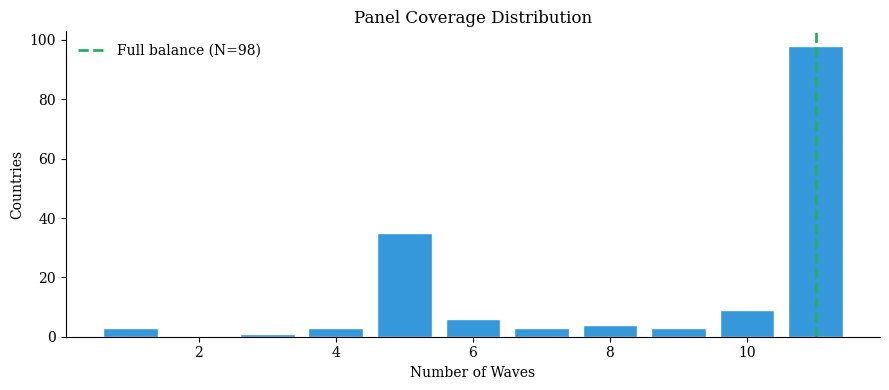

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(coverage_dist.index, coverage_dist.values, color='#3498db', edgecolor='white')
ax.axvline(x=len(QUIN), color='#27ae60', linestyle='--', linewidth=2,
           label=f'Full balance (N={len(balanced_countries)})')
ax.set_xlabel('Number of Waves')
ax.set_ylabel('Countries')
ax.set_title('Panel Coverage Distribution')
ax.legend()
plt.tight_layout()
efw.savefig(fig, 'quin_panel_coverage.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_panel_coverage.png', 'Coverage distribution',
              'Quinquennial', '1970-2020', f'{len(balanced_countries)} countries fully balanced')

## 3. Data Verification

Verify EFW = mean(5 areas) using difference analysis, not just correlation.

In [6]:
verify = efw.verify_index_construction(df, EFW, AREAS)
print(f"Index verification: max|diff| = {verify['max_abs_diff']:.4f}, r = {verify['correlation']:.6f}")
print("✓ Construction verified" if verify['max_abs_diff'] < 0.1 else "⚠ Check construction")

Index verification: max|diff| = 0.0050, r = 0.999997
✓ Construction verified


## 4. Global Trends: Balanced vs Unbalanced + Composition Wedge

**Question**: Are trends driven by sample composition or genuine change?

**Method**: Compare unbalanced and balanced sample means; show composition wedge.

In [7]:
# Compute stats for both samples
def compute_yearly_stats(data, col):
    """Compute mean, median, p10, p90, SD, count by year."""
    return data.groupby('Year')[col].agg([
        'mean', 'median', 'std', 'count',
        lambda x: x.quantile(0.10),
        lambda x: x.quantile(0.90)
    ]).rename(columns={'<lambda_0>': 'p10', '<lambda_1>': 'p90'})

yearly_unbal = compute_yearly_stats(df, EFW)
yearly_bal = compute_yearly_stats(df_bal, EFW)

# Composition wedge
wedge = yearly_unbal['mean'] - yearly_bal['mean']

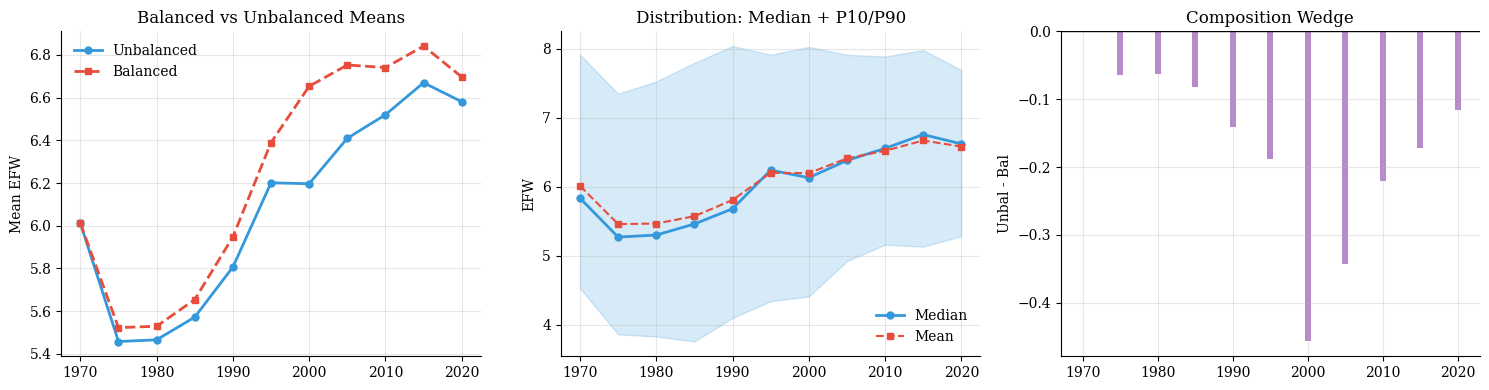

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Means comparison
ax = axes[0]
ax.plot(yearly_unbal.index, yearly_unbal['mean'], 'o-', color='#3498db', lw=2, ms=5, label='Unbalanced')
ax.plot(yearly_bal.index, yearly_bal['mean'], 's--', color='#e74c3c', lw=2, ms=5, label='Balanced')
ax.set_ylabel('Mean EFW')
ax.set_title('Balanced vs Unbalanced Means')
ax.legend()
ax.set_xticks(QUIN[::2])
ax.grid(alpha=0.3)

# Panel 2: Distribution bands (unbalanced)
ax = axes[1]
ax.fill_between(yearly_unbal.index, yearly_unbal['p10'], yearly_unbal['p90'], alpha=0.2, color='#3498db')
ax.plot(yearly_unbal.index, yearly_unbal['median'], 'o-', color='#3498db', lw=2, ms=5, label='Median')
ax.plot(yearly_unbal.index, yearly_unbal['mean'], 's--', color='#e74c3c', lw=1.5, ms=4, label='Mean')
ax.set_ylabel('EFW')
ax.set_title('Distribution: Median + P10/P90')
ax.legend()
ax.set_xticks(QUIN[::2])
ax.grid(alpha=0.3)

# Panel 3: Composition wedge
ax = axes[2]
ax.bar(wedge.index, wedge.values, color='#9b59b6', alpha=0.7)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Unbal - Bal')
ax.set_title('Composition Wedge')
ax.set_xticks(QUIN[::2])
ax.grid(alpha=0.3)

plt.tight_layout()
efw.savefig(fig, 'quin_global_trends.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_global_trends.png', 'Global trends: bal vs unbal + wedge',
              'Both', '1970-2020', 'Composition has modest effect; both show ~1.3pt gain')

**Key takeaways:**
- Both samples show ~1.3 point rise (5.6 → 6.9)
- Composition wedge is modest (<0.2 points)
- Trend is robust to sample definition

## 5. Component Trends: Distribution Bands + SD Over Time

**Question**: How did each area evolve? Which show convergence?

**Method**: Median + P10/P90 for each component; SD over time (bal vs unbal).

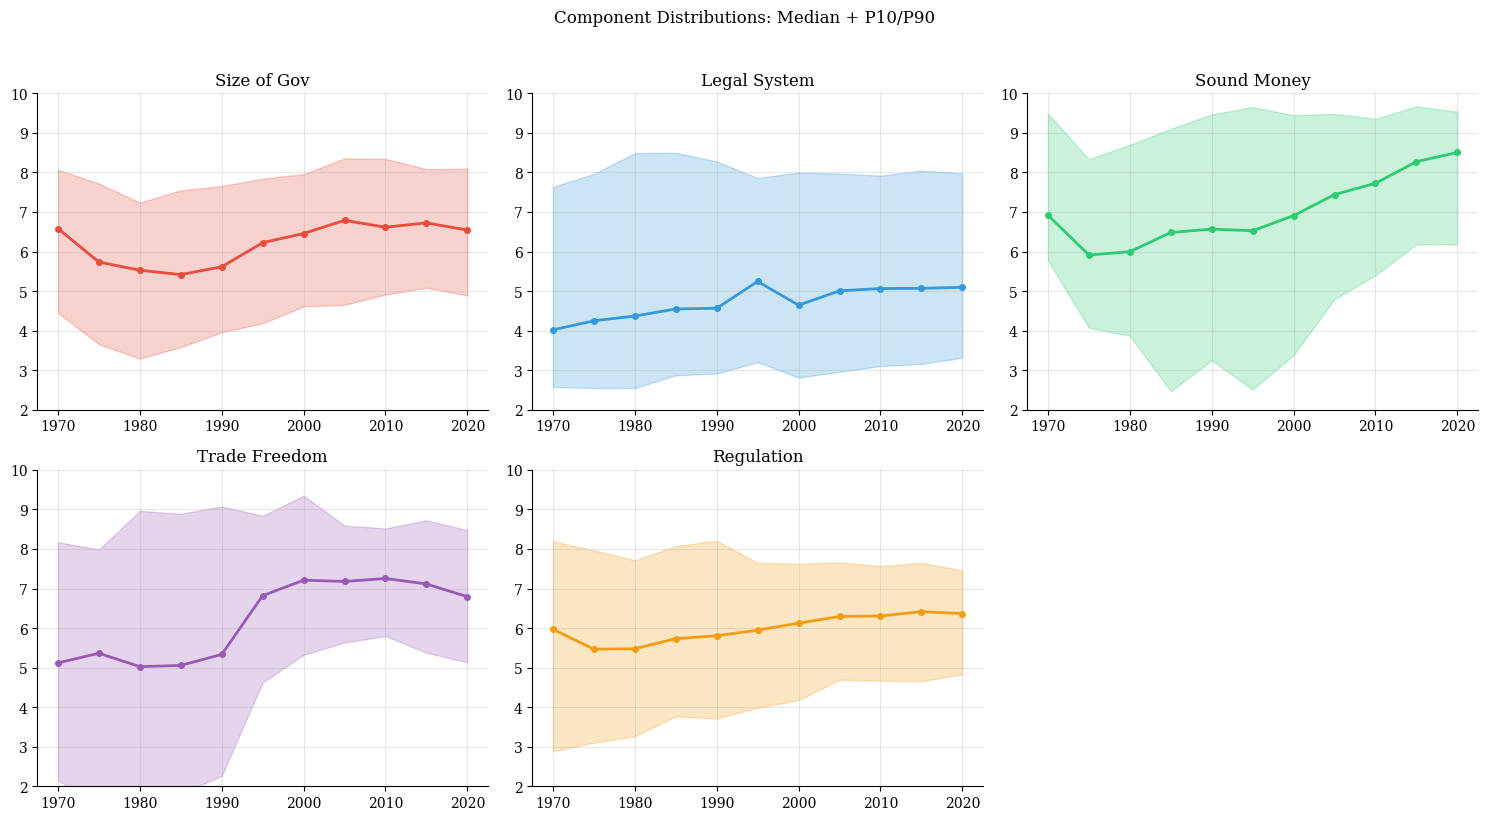

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (area, label, color) in enumerate(zip(AREAS, LABELS, COLORS)):
    ax = axes[i]
    stats_area = compute_yearly_stats(df, area)
    ax.fill_between(stats_area.index, stats_area['p10'], stats_area['p90'], alpha=0.25, color=color)
    ax.plot(stats_area.index, stats_area['median'], 'o-', color=color, lw=2, ms=4, label='Median')
    ax.set_title(label)
    ax.set_xticks(QUIN[::2])
    ax.set_ylim(2, 10)
    ax.grid(alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Component Distributions: Median + P10/P90', fontsize=12, y=1.02)
plt.tight_layout()
efw.savefig(fig, 'quin_component_distributions.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_component_distributions.png', 'Component median + IQR',
              'Unbalanced', '1970-2020', 'Sound Money: largest gain + biggest convergence')

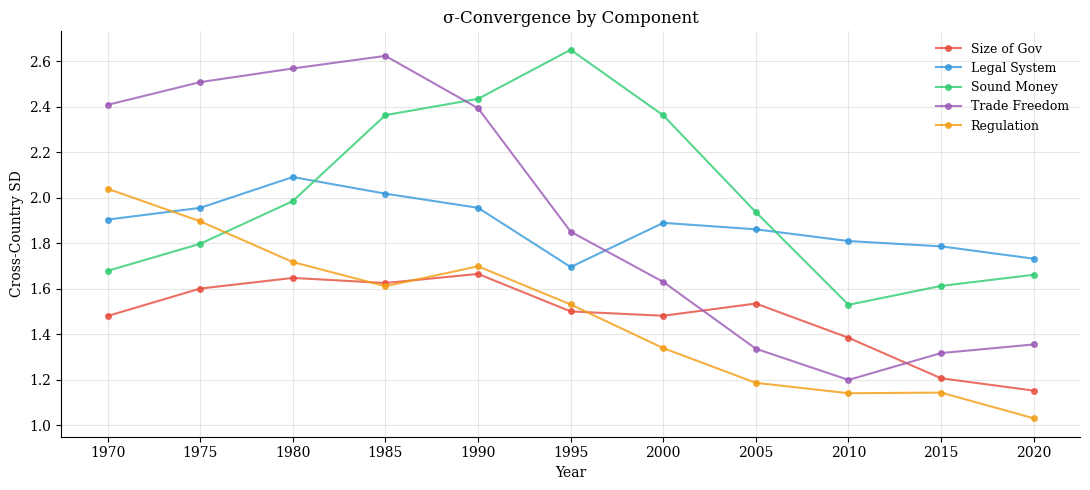

In [10]:
# SD over time for each component (bal vs unbal)
fig, ax = plt.subplots(figsize=(11, 5))

for area, label, color in zip(AREAS, LABELS, COLORS):
    sd_unbal = df.groupby('Year')[area].std()
    ax.plot(sd_unbal.index, sd_unbal.values, 'o-', color=color, lw=1.5, ms=4, alpha=0.8, label=label)

ax.set_xlabel('Year')
ax.set_ylabel('Cross-Country SD')
ax.set_title('σ-Convergence by Component')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(QUIN)
ax.grid(alpha=0.3)
plt.tight_layout()
efw.savefig(fig, 'quin_sigma_by_component.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_sigma_by_component.png', 'Component-level σ-convergence',
              'Unbalanced', '1970-2020', 'Sound Money converged most; Size of Gov stayed dispersed')

## 6. σ-Convergence: Balanced vs Unbalanced

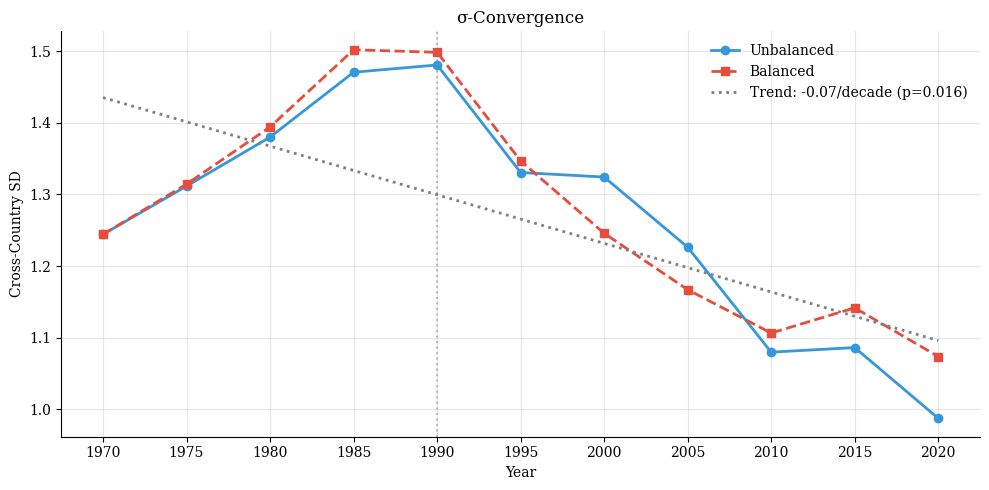

SD 1970→2020: 1.244 → 0.988
Trend: -0.068/decade (p=0.0161)


In [11]:
sigma_unbal = df.groupby('Year')[EFW].std()
sigma_bal = df_bal.groupby('Year')[EFW].std()

# Trend line (unbalanced)
slope, intercept, r, p, se = stats.linregress(sigma_unbal.index.astype(float), sigma_unbal.values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sigma_unbal.index, sigma_unbal.values, 'o-', color='#3498db', lw=2, ms=6, label='Unbalanced')
ax.plot(sigma_bal.index, sigma_bal.values, 's--', color='#e74c3c', lw=2, ms=6, label='Balanced')
ax.plot(sigma_unbal.index, intercept + slope * sigma_unbal.index.astype(float), ':', 
        color='gray', lw=2, label=f'Trend: {slope*10:.2f}/decade (p={p:.3f})')

ax.axvline(x=1990, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Cross-Country SD')
ax.set_title('σ-Convergence')
ax.legend()
ax.set_xticks(QUIN)
ax.grid(alpha=0.3)
plt.tight_layout()
efw.savefig(fig, 'quin_sigma_convergence.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_sigma_convergence.png', 'σ-convergence bal vs unbal',
              'Both', '1970-2020', f'SD fell from {sigma_unbal.iloc[0]:.2f} to {sigma_unbal.iloc[-1]:.2f}')

print(f"SD 1970→2020: {sigma_unbal.loc[1970]:.3f} → {sigma_unbal.loc[2020]:.3f}")
print(f"Trend: {slope*10:.3f}/decade (p={p:.4f})")

## 7. β-Convergence

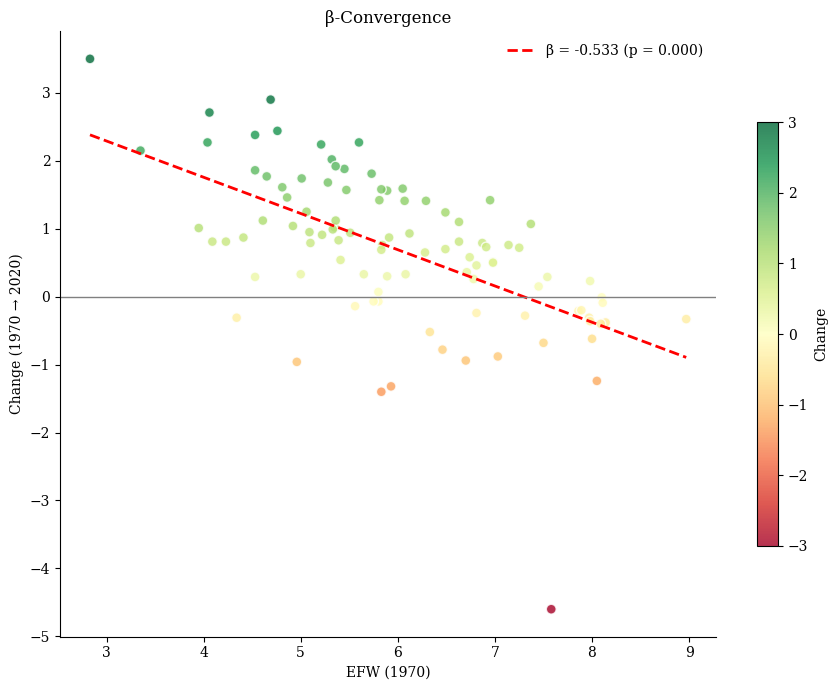

β = -0.533 (p = 0.0000), N = 98


In [12]:
beta = efw.compute_beta_convergence(df, 1970, 2020, EFW)

# Scatter
common = efw.get_common_countries(df, 1970, 2020, EFW)
df_1970 = df[df['Year'] == 1970].set_index('Countries')[EFW]
df_2020 = df[df['Year'] == 2020].set_index('Countries')[EFW]
scatter = pd.DataFrame({'start': df_1970.loc[common], 'end': df_2020.loc[common]}).dropna()
scatter['change'] = scatter['end'] - scatter['start']

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(scatter['start'], scatter['change'], c=scatter['change'], 
                cmap='RdYlGn', s=50, alpha=0.8, vmin=-3, vmax=3, edgecolors='white')

x_range = np.linspace(scatter['start'].min(), scatter['start'].max(), 100)
ax.plot(x_range, beta['intercept'] + beta['beta'] * x_range, 'r--', lw=2,
        label=f"β = {beta['beta']:.3f} (p = {beta['beta_p']:.3f})")
ax.axhline(0, color='gray', lw=1)
ax.set_xlabel('EFW (1970)')
ax.set_ylabel('Change (1970 → 2020)')
ax.set_title('β-Convergence')
ax.legend()
plt.colorbar(sc, shrink=0.7, label='Change')
plt.tight_layout()
efw.savefig(fig, 'quin_beta_convergence.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_beta_convergence.png', 'β-convergence scatter',
              'Common 1970-2020', '1970-2020', f'β = {beta["beta"]:.3f}; initially low countries caught up')

print(f"β = {beta['beta']:.3f} (p = {beta['beta_p']:.4f}), N = {beta['n']}")

## 8. Regional Analysis: Gap-to-World Plots

**Question**: Which regions are above/below global average, and how has this changed?

**Method**: Plot region_mean − world_mean over time (gap plots).

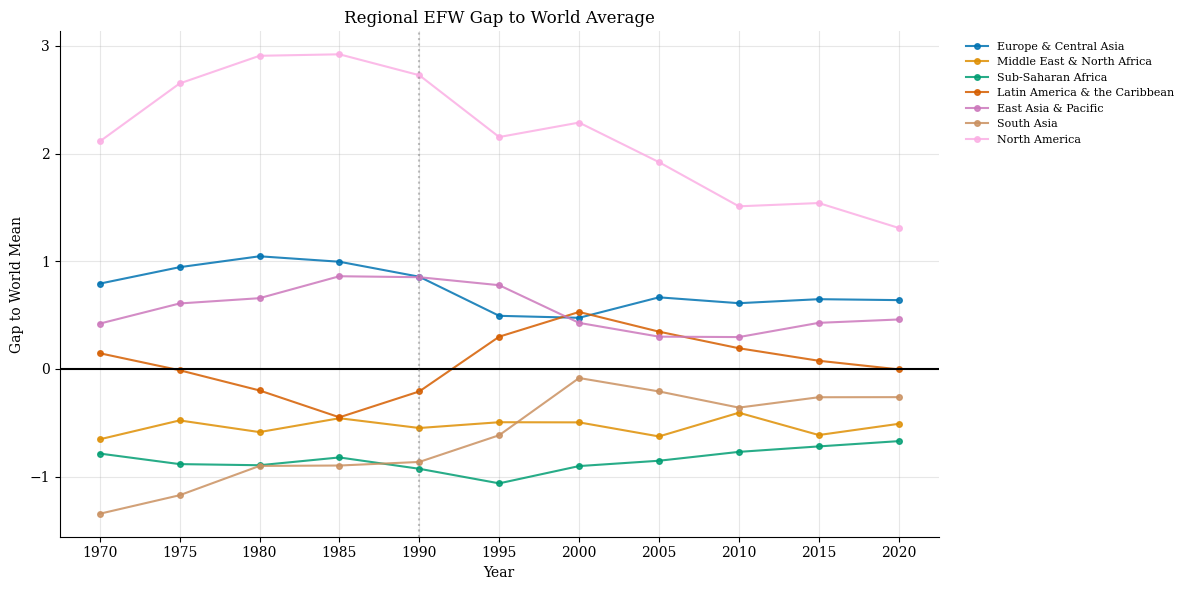


Latest regional gaps (2020):
  Europe & Central Asia                   : +0.64
  Middle East & North Africa              : -0.51
  Sub-Saharan Africa                      : -0.67
  Latin America & the Caribbean           : -0.00
  East Asia & Pacific                     : +0.46
  South Asia                              : -0.26
  North America                           : +1.31


In [13]:
# Compute gaps
world_mean = df.groupby('Year')[EFW].mean()
regions = df[REGION].dropna().unique()

gaps = {}
for region in regions:
    region_mean = df[df[REGION] == region].groupby('Year')[EFW].mean()
    gaps[region] = region_mean - world_mean

gaps_df = pd.DataFrame(gaps)

fig, ax = plt.subplots(figsize=(12, 6))
for region in gaps_df.columns:
    ax.plot(gaps_df.index, gaps_df[region], 'o-', lw=1.5, ms=4, alpha=0.85, label=region)

ax.axhline(0, color='black', lw=1.5)
ax.axvline(1990, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Gap to World Mean')
ax.set_title('Regional EFW Gap to World Average')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.set_xticks(QUIN)
ax.grid(alpha=0.3)
plt.tight_layout()
efw.savefig(fig, 'quin_regional_gaps.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_regional_gaps.png', 'Region - world mean over time',
              'Unbalanced', '1970-2020', 'North America +1 above; SSA -1 below; gaps persistent')

# Print latest gaps
print("\nLatest regional gaps (2020):")
for region in gaps_df.columns:
    print(f"  {region[:40]:40s}: {gaps_df.loc[2020, region]:+.2f}")

**Key takeaways:**
- North America consistently ~1 point above world average
- Sub-Saharan Africa consistently ~1 point below
- Europe & Central Asia gap narrowed (post-Soviet catch-up)

## 9. Gap Decomposition by Period

**Question**: Which components drive regional deviations from global average?

**Method**: For each period, show how region EFW gap change equals average of component gap changes.

In [14]:
# Gap decomposition table
decomp_rows = []
for region in regions:
    for start, end in PERIODS:
        region_data = df[df[REGION] == region]
        
        # EFW gap change
        efw_gap_start = region_data[region_data['Year'] == start][EFW].mean() - df[df['Year'] == start][EFW].mean()
        efw_gap_end = region_data[region_data['Year'] == end][EFW].mean() - df[df['Year'] == end][EFW].mean()
        efw_gap_change = efw_gap_end - efw_gap_start
        
        # Component gap changes
        comp_changes = {}
        for area, label in zip(AREAS, LABELS):
            comp_gap_start = region_data[region_data['Year'] == start][area].mean() - df[df['Year'] == start][area].mean()
            comp_gap_end = region_data[region_data['Year'] == end][area].mean() - df[df['Year'] == end][area].mean()
            comp_changes[label] = comp_gap_end - comp_gap_start
        
        row = {
            'Region': region,
            'Period': f'{start}→{end}',
            'EFW_Gap_Δ': efw_gap_change,
            **comp_changes
        }
        decomp_rows.append(row)

decomp_df = pd.DataFrame(decomp_rows)

# Show full gap decomposition
print("Regional Gap Changes by Period:")
print("=" * 60)
for period in [f'{s}→{e}' for s, e in PERIODS]:
    print(f"\n{period}:")
    period_data = decomp_df[decomp_df['Period'] == period].sort_values('EFW_Gap_Δ', ascending=False)
    for _, row in period_data.head(7).iterrows():
        print(f"  {row['Region'][:35]:35s}: {row['EFW_Gap_Δ']:+.3f}")

Regional Gap Changes by Period:

1990→2000:
  South Asia                         : +0.780
  Latin America & the Caribbean      : +0.738
  Middle East & North Africa         : +0.052
  Sub-Saharan Africa                 : +0.025
  Europe & Central Asia              : -0.382
  East Asia & Pacific                : -0.424
  North America                      : -0.440

2000→2010:
  Europe & Central Asia              : +0.136
  Sub-Saharan Africa                 : +0.132
  Middle East & North Africa         : +0.090
  East Asia & Pacific                : -0.132
  South Asia                         : -0.275
  Latin America & the Caribbean      : -0.337
  North America                      : -0.778

2010→2020:
  East Asia & Pacific                : +0.163
  Sub-Saharan Africa                 : +0.100
  South Asia                         : +0.097
  Europe & Central Asia              : +0.029
  Middle East & North Africa         : -0.103
  Latin America & the Caribbean      : -0.196
  North Amer

## 10. Rank Persistence

Rank persistence by period:
  1970–1975: ρ = 0.863
  1975–1980: ρ = 0.882
  1980–1985: ρ = 0.910
  1985–1990: ρ = 0.912
  1990–1995: ρ = 0.898
  1995–2000: ρ = 0.942
  2000–2005: ρ = 0.954
  2005–2010: ρ = 0.959
  2010–2015: ρ = 0.969
  2015–2020: ρ = 0.974


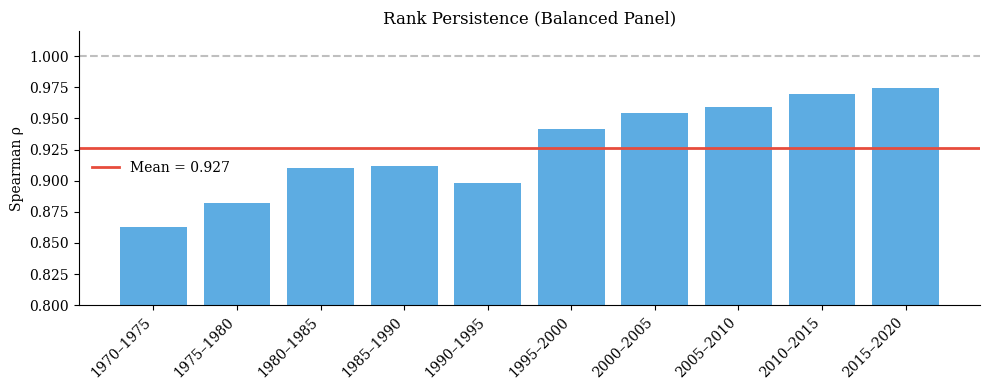

In [15]:
ranks = df_bal.pivot_table(index='Countries', columns='Year', values=EFW)

results = []
for i in range(len(QUIN) - 1):
    y1, y2 = QUIN[i], QUIN[i+1]
    valid = ranks[[y1, y2]].dropna()
    rho, _ = stats.spearmanr(valid[y1], valid[y2])
    results.append({'Period': f'{y1}–{y2}', 'Rho': rho})

rank_df = pd.DataFrame(results)
print("Rank persistence by period:")
for _, row in rank_df.iterrows():
    print(f"  {row['Period']}: ρ = {row['Rho']:.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(rank_df)), rank_df['Rho'], color='#3498db', alpha=0.8)
ax.axhline(1, color='gray', linestyle='--', alpha=0.5)
ax.axhline(rank_df['Rho'].mean(), color='#e74c3c', lw=2, label=f"Mean = {rank_df['Rho'].mean():.3f}")
ax.set_xticks(range(len(rank_df)))
ax.set_xticklabels(rank_df['Period'], rotation=45, ha='right')
ax.set_ylabel("Spearman ρ")
ax.set_title('Rank Persistence (Balanced Panel)')
ax.set_ylim(0.8, 1.02)
ax.legend()
plt.tight_layout()
efw.savefig(fig, 'quin_rank_persistence.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_rank_persistence.png', 'Rank persistence between waves',
              'Balanced', '1970-2020', f'Mean ρ = {rank_df["Rho"].mean():.2f}; high stability')

## 11. Transition Matrices: Relative vs Absolute (Fixed) Cutoffs

**Question**: How do mobility measures differ when using relative vs absolute thresholds?

**Method**: Two transition matrices + Shorrocks mobility index for each.

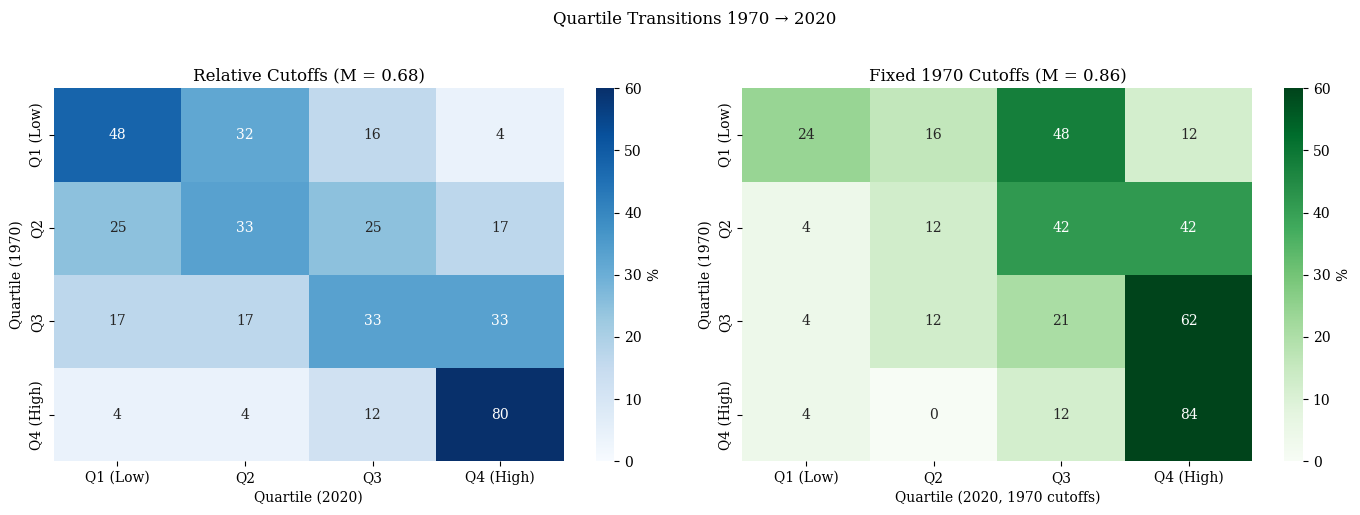

Shorrocks Mobility Index:
  Relative cutoffs: 0.684
  Fixed 1970 cutoffs: 0.862


In [16]:
# Relative cutoffs
trans_rel, _, meta_rel = efw.compute_transition_matrix(df, 1970, 2020, EFW, n_quantiles=4, fixed_cutoffs=False)
shorrocks_rel = efw.compute_shorrocks_mobility(trans_rel)

# Fixed cutoffs (1970 thresholds)
trans_fix, _, meta_fix = efw.compute_transition_matrix(df, 1970, 2020, EFW, n_quantiles=4, fixed_cutoffs=True)
shorrocks_fix = efw.compute_shorrocks_mobility(trans_fix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.heatmap(trans_rel, annot=True, fmt='.0f', cmap='Blues', ax=ax, vmin=0, vmax=60, cbar_kws={'label': '%'})
ax.set_xlabel('Quartile (2020)')
ax.set_ylabel('Quartile (1970)')
ax.set_title(f'Relative Cutoffs (M = {shorrocks_rel:.2f})')

ax = axes[1]
sns.heatmap(trans_fix, annot=True, fmt='.0f', cmap='Greens', ax=ax, vmin=0, vmax=60, cbar_kws={'label': '%'})
ax.set_xlabel('Quartile (2020, 1970 cutoffs)')
ax.set_ylabel('Quartile (1970)')
ax.set_title(f'Fixed 1970 Cutoffs (M = {shorrocks_fix:.2f})')

plt.suptitle('Quartile Transitions 1970 → 2020', fontsize=12, y=1.02)
plt.tight_layout()
efw.savefig(fig, 'quin_transition_matrices.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_transition_matrices.png', 'Relative vs fixed transition matrices',
              'Common 1970-2020', '1970-2020', f'Shorrocks: rel={shorrocks_rel:.2f}, fix={shorrocks_fix:.2f}')

print(f"Shorrocks Mobility Index:")
print(f"  Relative cutoffs: {shorrocks_rel:.3f}")
print(f"  Fixed 1970 cutoffs: {shorrocks_fix:.3f}")

**Key takeaways:**
- Relative matrix shows ~40% diagonal persistence
- Fixed matrix shows upward shift (most countries improved)
- Lower persistence in fixed = absolute progress, not just relative reshuffling

## 12. Reform Intensity: Large Moves by Region/Decade

**Question**: When and where did large reforms/reversals occur?

**Method**: Count |ΔEFW| > 1.0 by region and decade; list top movers with component drivers.

In [17]:
# Compute wave-to-wave changes
changes_list = []
for i in range(len(QUIN) - 1):
    y1, y2 = QUIN[i], QUIN[i+1]
    df1 = df[df['Year'] == y1].set_index('Countries')[[EFW, REGION] + AREAS]
    df2 = df[df['Year'] == y2].set_index('Countries')[[EFW] + AREAS]
    
    common = list(set(df1.index) & set(df2.index))
    for country in common:
        change = df2.loc[country, EFW] - df1.loc[country, EFW]
        if pd.notna(change):
            row = {
                'Country': country,
                'Period': f'{y1}→{y2}',
                'Decade': (y1 // 10) * 10,
                'Region': df1.loc[country, REGION],
                'EFW_Change': change
            }
            # Component changes
            for area, label in zip(AREAS, LABELS):
                row[f'{label}_Δ'] = df2.loc[country, area] - df1.loc[country, area]
            changes_list.append(row)

changes_df = pd.DataFrame(changes_list)

# Large moves: |ΔEFW| > 1.0
big_moves = changes_df[changes_df['EFW_Change'].abs() > 1.0].copy()
big_moves['Type'] = np.where(big_moves['EFW_Change'] > 0, 'Reform', 'Reversal')

print(f"Large moves (|Δ|>1.0): {len(big_moves)} out of {len(changes_df)} ({100*len(big_moves)/len(changes_df):.1f}%)")

Large moves (|Δ|>1.0): 113 out of 1312 (8.6%)


In [18]:
# Count by region and decade
reform_counts = big_moves.groupby(['Region', 'Decade', 'Type']).size().unstack(fill_value=0)

# Summary
type_summary = big_moves.groupby('Type').size()
print(f"\nTotal large moves: {len(big_moves)}")
print(f"  Reforms: {type_summary.get('Reform', 0)}")
print(f"  Reversals: {type_summary.get('Reversal', 0)}")

print("\nBy decade:")
for decade in sorted(big_moves['Decade'].unique()):
    decade_data = big_moves[big_moves['Decade'] == decade]
    n_ref = len(decade_data[decade_data['Type'] == 'Reform'])
    n_rev = len(decade_data[decade_data['Type'] == 'Reversal'])
    print(f"  {decade}s: {n_ref} reforms, {n_rev} reversals")


Total large moves: 113
  Reforms: 74
  Reversals: 39

By decade:
  1970s: 4 reforms, 25 reversals
  1980s: 15 reforms, 3 reversals
  1990s: 32 reforms, 1 reversals
  2000s: 19 reforms, 6 reversals
  2010s: 4 reforms, 4 reversals


In [19]:
# Top 10 reforms and reversals with component drivers
top_reforms = big_moves[big_moves['Type'] == 'Reform'].nlargest(10, 'EFW_Change')
top_reversals = big_moves[big_moves['Type'] == 'Reversal'].nsmallest(10, 'EFW_Change')

# Find which component drove each move (handle NaNs properly)
def get_driver(row):
    vals = []
    for label in LABELS:
        v = row.get(f'{label}_Δ', np.nan)
        if pd.notna(v):
            vals.append((abs(v), label))
    return max(vals, key=lambda x: x[0])[1] if vals else None

top_reforms['Driver'] = top_reforms.apply(get_driver, axis=1)
top_reversals['Driver'] = top_reversals.apply(get_driver, axis=1)

# Print full lists
print("\nTop 10 Reforms:")
print("-" * 60)
for _, row in top_reforms.iterrows():
    print(f"  {row['Country']:25s} {row['Period']:12s} Δ={row['EFW_Change']:+.2f}  ({row['Driver']})")

print("\nTop 10 Reversals:")
print("-" * 60)
for _, row in top_reversals.iterrows():
    print(f"  {row['Country']:25s} {row['Period']:12s} Δ={row['EFW_Change']:+.2f}  ({row['Driver']})")


Top 10 Reforms:
------------------------------------------------------------
  Nicaragua                 1990→1995    Δ=+2.85  (Sound Money)
  Uganda                    1990→1995    Δ=+2.33  (Sound Money)
  Argentina                 1990→1995    Δ=+2.14  (Sound Money)
  Peru                      1990→1995    Δ=+2.10  (Sound Money)
  El Salvador               1990→1995    Δ=+2.02  (Sound Money)
  Qatar                     2005→2010    Δ=+1.96  (Size of Gov)
  Armenia                   2000→2005    Δ=+1.88  (Sound Money)
  Belarus                   2015→2020    Δ=+1.88  (Sound Money)
  Romania                   2000→2005    Δ=+1.79  (Sound Money)
  Yemen, Rep.               2005→2010    Δ=+1.75  (Sound Money)

Top 10 Reversals:
------------------------------------------------------------
  Argentina                 1970→1975    Δ=-2.43  (Sound Money)
  Botswana                  1970→1975    Δ=-2.14  (Sound Money)
  Trinidad and Tobago       1970→1975    Δ=-2.04  (Sound Money)
  Zimbabwe

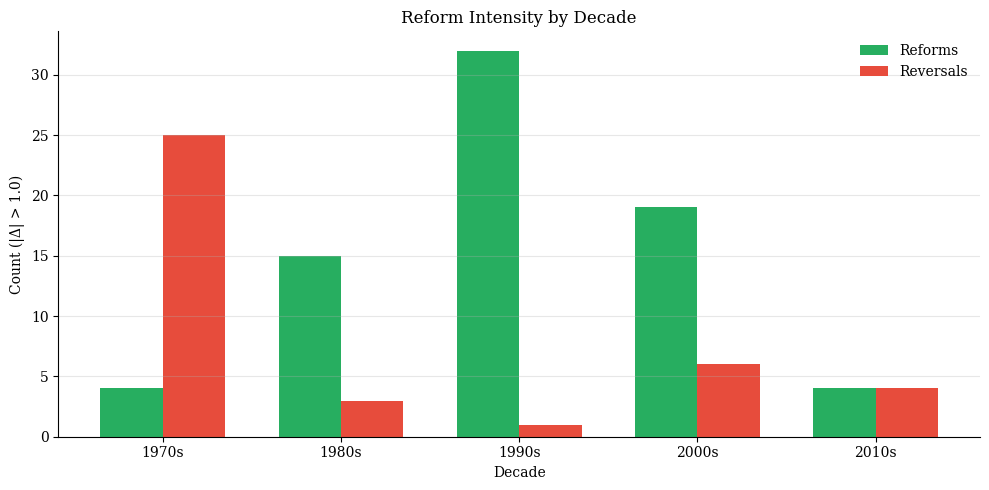

In [20]:
# Visualize reform intensity by decade
fig, ax = plt.subplots(figsize=(10, 5))

decades = sorted(big_moves['Decade'].unique())
reforms_by_decade = big_moves[big_moves['Type'] == 'Reform'].groupby('Decade').size()
reversals_by_decade = big_moves[big_moves['Type'] == 'Reversal'].groupby('Decade').size()

x = np.arange(len(decades))
width = 0.35

ax.bar(x - width/2, [reforms_by_decade.get(d, 0) for d in decades], width, label='Reforms', color='#27ae60')
ax.bar(x + width/2, [reversals_by_decade.get(d, 0) for d in decades], width, label='Reversals', color='#e74c3c')

ax.set_xlabel('Decade')
ax.set_ylabel('Count (|Δ| > 1.0)')
ax.set_title('Reform Intensity by Decade')
ax.set_xticks(x)
ax.set_xticklabels([f'{d}s' for d in decades])
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
efw.savefig(fig, 'quin_reform_intensity.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_reform_intensity.png', 'Large moves by decade',
              'Unbalanced', '1970-2020', '1990s saw most reforms; reversals relatively rare')

## 13. Notable Countries: Reformers, Reversals, Volatile

**Question**: Which countries show the most distinctive patterns?

**Method**: Auto-select top improvers, decliners, and volatile; show compact dashboard.

Using fixed window: 1970→2020


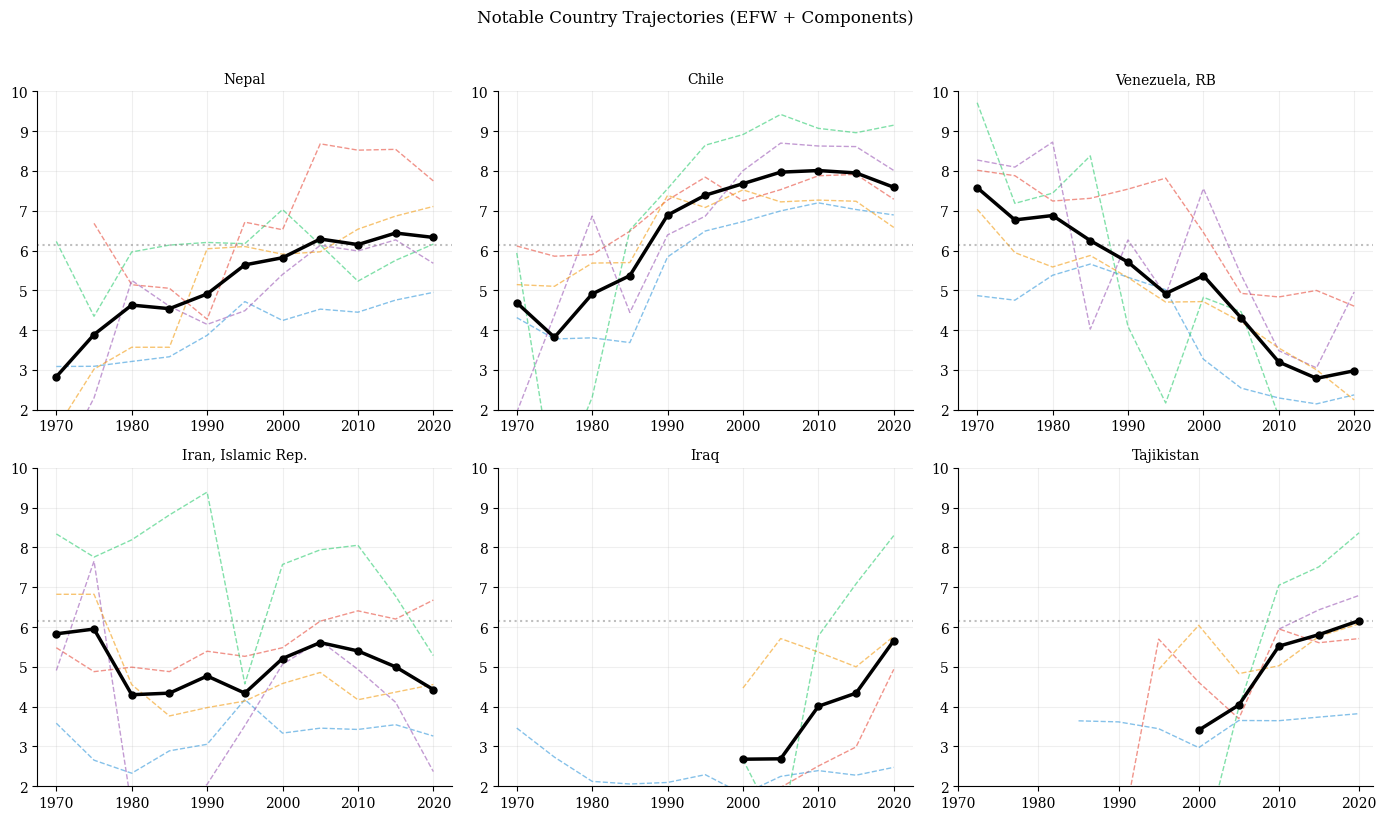


Notable Countries:
  Reformers: Nepal, Chile, Uganda, Hungary, Indonesia
  Reversals: Venezuela, RB, Iran, Islamic Rep., Argentina, Barbados, Zimbabwe
  Volatile: Iraq, Tajikistan, Venezuela, RB, Serbia, Argentina


In [21]:
notable = efw.select_notable_countries(df, EFW, start_year=1970, end_year=2020)
print(f"Using fixed window: {notable['start_year']}→{notable['end_year']}")

# Pick 2 from each category
reformers = notable['top_reformers'][:2]
reversals = notable['top_reversals'][:2]
volatiles = [c for c in notable['volatile'][:2] if c not in reformers + reversals]

selected = reformers + reversals + volatiles[:2]
selected = list(dict.fromkeys(selected))[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, country in enumerate(selected):
    ax = axes[i]
    cdata = df[df['Countries'] == country].sort_values('Year')
    
    ax.plot(cdata['Year'], cdata[EFW], 'ko-', lw=2.5, ms=5, label='EFW', zorder=10)
    for area, label, color in zip(AREAS, LABELS, COLORS):
        ax.plot(cdata['Year'], cdata[area], '--', color=color, lw=1, alpha=0.6)
    
    ax.axhline(y=df[EFW].mean(), color='gray', linestyle=':', alpha=0.5)
    ax.set_title(country, fontsize=10)
    ax.set_ylim(2, 10)
    ax.set_xticks(QUIN[::2])
    ax.grid(alpha=0.2)

plt.suptitle('Notable Country Trajectories (EFW + Components)', fontsize=12, y=1.02)
plt.tight_layout()
efw.savefig(fig, 'quin_notable_countries.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_notable_countries.png', 'Selected country dashboards',
              'Selected', '1970-2020', 'Reformers vs reversals: distinct component patterns')

# Print notable countries
print("\nNotable Countries:")
print("  Reformers:", ', '.join(notable['top_reformers'][:5]))
print("  Reversals:", ', '.join(notable['top_reversals'][:5]))
print("  Volatile:", ', '.join(notable['volatile'][:5]))

## 14. Cluster Analysis

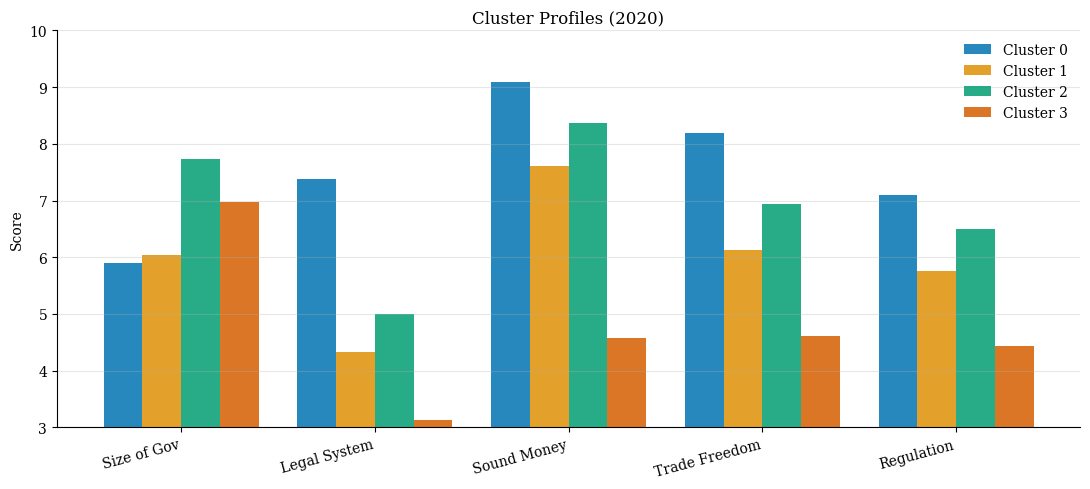


Cluster Assignments (2020):
Cluster
0    50
1    54
2    45
3    16


In [22]:
# 2020 cross-section with complete data
df_2020 = df[df['Year'] == 2020][['Countries', REGION, INCOME, EFW] + AREAS].dropna()

scaler = StandardScaler()
X = scaler.fit_transform(df_2020[AREAS])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_2020['Cluster'] = kmeans.fit_predict(X)

centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=LABELS)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(LABELS))
width = 0.2
for i in range(4):
    ax.bar(x + i*width, centers.iloc[i].values, width, alpha=0.85, label=f'Cluster {i}')

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(LABELS, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Cluster Profiles (2020)')
ax.legend()
ax.set_ylim(3, 10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
efw.savefig(fig, 'quin_cluster_profiles.png', OUTPUT_DIR)
plt.show()

fig_index.add('quin_cluster_profiles.png', 'K-means cluster centers',
              '2020', '2020', '4 distinct profiles based on 5 components')

# Print cluster summary
print("\nCluster Assignments (2020):")
print(df_2020.groupby('Cluster')['Countries'].count().to_string())

In [23]:
fig_index.save(OUTPUT_DIR)

summary = pd.DataFrame({
    'Metric': ['EFW 1970', 'EFW 2020', 'Change', 'SD 1970', 'SD 2020', 
               'Mean ρ', 'Shorrocks (rel)', 'β-coefficient', 'Large reforms', 'Large reversals'],
    'Value': [f"{yearly_unbal.loc[1970, 'mean']:.2f}", f"{yearly_unbal.loc[2020, 'mean']:.2f}",
              f"{yearly_unbal.loc[2020, 'mean'] - yearly_unbal.loc[1970, 'mean']:+.2f}",
              f"{sigma_unbal.loc[1970]:.2f}", f"{sigma_unbal.loc[2020]:.2f}",
              f"{rank_df['Rho'].mean():.2f}", f"{shorrocks_rel:.2f}", f"{beta['beta']:.3f}",
              f"{type_summary.get('Reform', 0)}", f"{type_summary.get('Reversal', 0)}"]
})
summary.to_csv(f'{TABLES_DIR}/quin_summary.csv', index=False)

print("\n" + "=" * 60)
print("QUINQUENNIAL ANALYSIS COMPLETE")
print("=" * 60)
print(summary.to_string(index=False))


QUINQUENNIAL ANALYSIS COMPLETE
         Metric  Value
       EFW 1970   6.01
       EFW 2020   6.58
         Change  +0.57
        SD 1970   1.24
        SD 2020   0.99
         Mean ρ   0.93
Shorrocks (rel)   0.68
  β-coefficient -0.533
  Large reforms     74
Large reversals     39
